In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings

# Set a clean plot style for our notebook visualizations
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

In [3]:
print("Fetching data from Hugging Face (muse-bench/MUSE-News)...")

# Load the 'raw' text subset splits
try:
    forget_hf = load_dataset("muse-bench/MUSE-News", "raw", split="forget")
    retain1_hf = load_dataset("muse-bench/MUSE-News", "raw", split="retain1")
    retain2_hf = load_dataset("muse-bench/MUSE-News", "raw", split="retain2")
    holdout_hf = load_dataset("muse-bench/MUSE-News", "raw", split="holdout")
    
    # Convert them to Pandas DataFrames for easy exploration
    forget_df = forget_hf.to_pandas()
    retain_df = pd.concat([retain1_hf.to_pandas(), retain2_hf.to_pandas()], ignore_index=True)
    holdout_df = holdout_hf.to_pandas()
    
    print("Successfully loaded and converted raw text splits to DataFrames!")
except Exception as e:
    print(f"Error loading from Hugging Face: {e}")

Fetching data from Hugging Face (muse-bench/MUSE-News)...


README.md: 0.00B [00:00, ?B/s]

raw/retain2-00000-of-00001.parquet:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

raw/forget-00000-of-00001.parquet:   0%|          | 0.00/1.93M [00:00<?, ?B/s]

raw/retain1-00000-of-00001.parquet:   0%|          | 0.00/3.73M [00:00<?, ?B/s]

...

Generating retain2 split:   0%|          | 0/1778 [00:00<?, ? examples/s]

Generating forget split:   0%|          | 0/889 [00:00<?, ? examples/s]

Generating retain1 split:   0%|          | 0/1777 [00:00<?, ? examples/s]

Generating holdout split:   0%|          | 0/3043 [00:00<?, ? examples/s]

Successfully loaded and converted raw text splits to DataFrames!


In [4]:
print(f"Forget Set Size:  {len(forget_df):,} records")
print(f"Retain Set Size:  {len(retain_df):,} records (retain1 + retain2)")
print(f"Holdout Set Size: {len(holdout_df):,} records")

print("\n--- Available Columns ---")
print(forget_df.columns.tolist())

print("\n--- Sample Record (Forget Set Text) ---")
display(forget_df.head(2))

Forget Set Size:  889 records
Retain Set Size:  3,555 records (retain1 + retain2)
Holdout Set Size: 3,043 records

--- Available Columns ---
['text']

--- Sample Record (Forget Set Text) ---


,text
0,Greek Prime Minister Kyriakos Mitsotakis has a...
1,DUP Leader says his party is happy to be invol...


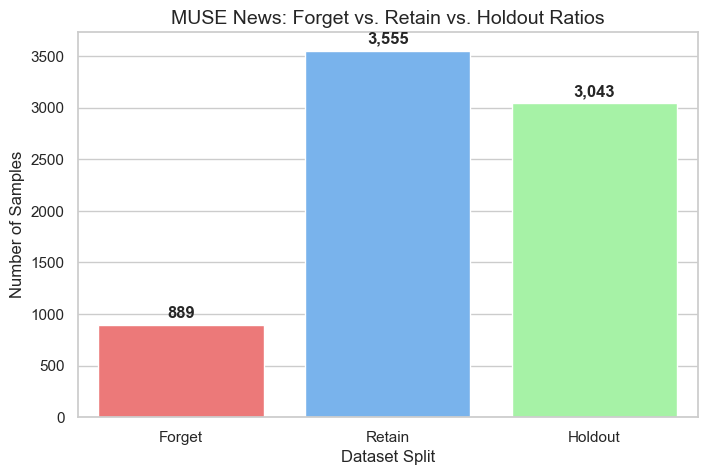

In [5]:
splits = ['Forget', 'Retain', 'Holdout']
counts = [len(forget_df), len(retain_df), len(holdout_df)]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=splits, y=counts, palette=['#ff6666','#66b3ff','#99ff99'])
plt.title('MUSE News: Forget vs. Retain vs. Holdout Ratios', fontsize=14)
plt.ylabel('Number of Samples')
plt.xlabel('Dataset Split')

for i, v in enumerate(counts):
    ax.text(i, v + (max(counts)*0.02), f"{v:,}", ha='center', fontweight='bold')

plt.show()

In [6]:
print("Fetching the Knowledge Memorization (Q&A) subset...")

# Load the specific Q&A splits for evaluation
forget_qa_hf = load_dataset("muse-bench/MUSE-News", "knowmem", split="forget_qa")
retain_qa_hf = load_dataset("muse-bench/MUSE-News", "knowmem", split="retain_qa")

forget_qa_df = forget_qa_hf.to_pandas()
retain_qa_df = retain_qa_hf.to_pandas()

print(f"\nLoaded {len(forget_qa_df)} Forget Q&A pairs and {len(retain_qa_df)} Retain Q&A pairs.")

print("\n--- Sample Forget Evaluation Questions ---")
# These are questions the unlearned model should struggle to answer
display(forget_qa_df[['question', 'answer']].sample(n=3, random_state=42))

Fetching the Knowledge Memorization (Q&A) subset...


knowmem/retain_qa_icl-00000-of-00001.par(…):   0%|          | 0.00/2.90k [00:00<?, ?B/s]

knowmem/retain_qa-00000-of-00001.parquet:   0%|          | 0.00/10.8k [00:00<?, ?B/s]

knowmem/forget_qa-00000-of-00001.parquet:   0%|          | 0.00/9.99k [00:00<?, ?B/s]

knowmem/forget_qa_icl-00000-of-00001.par(…):   0%|          | 0.00/2.91k [00:00<?, ?B/s]

...

Generating retain_qa split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating forget_qa split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating forget_qa_icl split:   0%|          | 0/10 [00:00<?, ? examples/s]


Loaded 100 Forget Q&A pairs and 100 Retain Q&A pairs.

--- Sample Forget Evaluation Questions ---


,question,answer
83,"According to the excerpt, how many homes are e...",4.6 million homes
53,Who was appointed Secretary of State for Cultu...,Lucy Frazer
70,What specific action did the Commons standards...,an eight-week suspension from the Commons


In [8]:
import pandas as pd
from datasets import load_dataset

# Set pandas to show the full width of the text column without truncating
pd.set_option('display.max_colwidth', None)

print("Fetching raw Forget text from Hugging Face...")
# Load only the raw forget split
forget_raw = load_dataset("muse-bench/MUSE-News", "raw", split="forget").to_pandas()

print(f"Total Forget Articles: {len(forget_raw)}\n")
print("--- Peek at the actual Forget Data Text ---")

# Display the first 3 full text entries
display(forget_raw[['text']].head(10))

Fetching raw Forget text from Hugging Face...
Total Forget Articles: 889

--- Peek at the actual Forget Data Text ---


text
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  Greek Prime Minister Kyriakos Mitsotakis has asked for forgiveness from the families of the 57 victims of this week's train crash.\n\nIn a Facebook message, Mr Mitsotakis said that "in the Greece of 2023... two trains heading in different directions cannot run on the same line and no-one notice".\n\nClashes with police were reported on Sunday as thousands joined a demonstration in the capital Athens.\n\nThey said seven officers were hurt and five arrests were made, the AFP news agency reports.\n\nSome demonstrators set fire to rubbish bins and threw petrol bombs. Police responded by firing tear gas and stun grenades, clearing the central Syntagma Square of the protesters within a few minutes.\n\nThe protesters also reportedly released hundreds of black balloons into the sky in memory of the dead, with some holding signs reading "Down with killer governments".\n\nOn the night of 28 February, a passenger train and a freight train that were travelling in opposite directions ended up on the same track.\n\nThe first four carriages of the passenger train were derailed, and the first two caught fire and were almost completely destroyed.\n\nThe train crash has been widely attributed to human error.\n\nA 59-year-old station master in Larissa, who was charged with manslaughter by negligence, appeared in court on Sunday and has been taken into custody.\n\nHis lawyer Stefan

In [9]:
search_term = "government" # Change this to any keyword you are looking for

# Filter the dataframe for rows where the text contains your search term (case-insensitive)
matches = forget_raw[forget_raw['text'].str.contains(search_term, case=False, na=False)]

print(f"Found {len(matches)} articles in the Forget set containing '{search_term}'.")

# Display the first match if it exists
if not matches.empty:
    display(matches[['text']].head(1))

Found 295 articles in the Forget set containing 'government'.


,text
0,"Greek Prime Minister Kyriakos Mitsotakis has asked for forgiveness from the families of the 57 victims of this week's train crash.\n\nIn a Facebook message, Mr Mitsotakis said that ""in the Greece of 2023... two trains heading in different directions cannot run on the same line and no-one notice"".\n\nClashes with police were reported on Sunday as thousands joined a demonstration in the capital Athens.\n\nThey said seven officers were hurt and five arrests were made, the AFP news agency reports.\n\nSome demonstrators set fire to rubbish bins and threw petrol bombs. Police responded by firing tear gas and stun grenades, clearing the central Syntagma Square of the protesters within a few minutes.\n\nThe protesters also reportedly released hundreds of black balloons into the sky in memory of the dead, with some holding signs reading ""Down with killer governments"".\n\nOn the night of 28 February, a passenger train and a freight train that were travelling in opposite directions ended up on the same track.\n\nThe first four carriages of the passenger train were derailed, and the first two caught fire and were almost completely destroyed.\n\nThe train crash has been widely attributed to human error.\n\nA 59-year-old station master in Larissa, who was charged with manslaughter by negligence, appeared in court on Sunday and has been taken into custody.\n\nHis lawyer Stefanos Pantzartzidis said the station master had admitted to having a share of responsibility in the accident. He faces between 10 years and life in jail if convicted.\n\nBut many in Greece see the crash as an accident that had been waiting to happen, and the railway workers' union blamed successive governments' ""disrespect"" towards Greek railways for leading to this ""tragic result"".\n\nA government minister told the BBC that the lack of funding was the direct result of the strict terms of international bailouts imposed after the 2010 debt crisis.\n\nThe scene of the crash near Larissa\n\nUnion members were joined by residents of Athens and Thessaloniki in taking to the streets throughout the past week, shocked by the scale of the disaster. The protests were also attended by many students - several of the passengers on board one of the trains were students in their 20s returning to Thessaloniki after a long weekend celebrating Greek Orthodox Lent.\n\n""The rail network looked problematic, with worn down, badly paid staff,"" Nikos Savva, a medical student from Cyprus, told AFP news agency.\n\nTrain drivers in Greece have said there have been long-running problems with the electronic systems that are supposed to warn them of danger ahead.\n\nThe transport minister, Kostas Karamanlis, also resigned as a ""sign of respect"" for the people who had died. Mr Karamanlis he was taking responsibility for the government's failure to modernise the country's railways in the three-and-a-half years it had been in power.\n\nImmediately after the accident, the Greek government declared three days of national mourning and said the cost of the victims' funerals would be paid for from the public purse.\n\nBBC Europe correspondent Nick Beake says the crash seems to be becoming a defining political issue for Greece as it prepares to face a general election in the spring.\n\nMedia reports have given 9 April as a possible date, but analysts say that date may now be pushed back."
